In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


In [2]:
def formatar_numero(valor, casas_decimais=0):
    """Formatar número para formato mais legível"""
    if pd.isna(valor) or valor == 0:
        return "0"
    
    if valor >= 1_000_000_000:
        return f"${valor/1_000_000_000:.2f}B"
    elif valor >= 1_000_000:
        return f"${valor/1_000_000:.2f}M"
    elif valor >= 1_000:
        return f"${valor/1_000:.1f}K"
    else:
        return f"${valor:,.{casas_decimais}f}"

def formatar_dataframe_gross(df):
    """Formatar colunas Gross em um DataFrame"""
    df_formatado = df.copy()
    for col in df_formatado.columns:
        if 'Gross' in str(col):
            if df_formatado[col].dtype in [np.int64, np.float64]:
                df_formatado[col] = df_formatado[col].apply(
                    lambda x: formatar_numero(x) if isinstance(x, (int, float)) else x
                )
    return df_formatado

In [3]:
caminho_arquivo = 'desafio_indicium_imdb.csv'

try:
    df = pd.read_csv(caminho_arquivo)
    print(f"✅ Dataset carregado com sucesso!")
    print(f"📊 Shape do dataset: {df.shape}")
    print(f"📋 Colunas: {df.columns.tolist()}")
    
except FileNotFoundError:
    print(f"❌ Arquivo {caminho_arquivo} não encontrado!")
    print("⚠️ Verifique o caminho do arquivo")

✅ Dataset carregado com sucesso!
📊 Shape do dataset: (999, 16)
📋 Colunas: ['Unnamed: 0', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


In [4]:
print("PRÉ-PROCESSAMENTO")
print("=" * 40)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("✅ Coluna 'Unnamed: 0' removida")

print("\n📊 DADOS FALTANTES:")
print(df.isnull().sum())

PRÉ-PROCESSAMENTO
✅ Coluna 'Unnamed: 0' removida

📊 DADOS FALTANTES:
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [5]:
def limpar_valor_monetario(valor):
    """Limpar valores monetários da coluna Gross"""
    if pd.isna(valor):
        return 0
    if isinstance(valor, str):
        valor_limpo = ''.join(c for c in valor if c.isdigit() or c == '.')
        return float(valor_limpo) if valor_limpo else 0
    return float(valor)

def limpar_runtime(valor):
    """Extrair minutos da coluna Runtime"""
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, str):
        numeros = re.findall(r'\d+', valor)
        return int(numeros[0]) if numeros else np.nan
    return valor

df['Gross'] = df['Gross'].apply(limpar_valor_monetario)
df['Runtime'] = df['Runtime'].apply(limpar_runtime)

print("✅ Colunas Gross e Runtime limpas")

✅ Colunas Gross e Runtime limpas


In [6]:
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
df['Runtime'] = df['Runtime'].fillna(df['Runtime'].median())
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'] = df['Released_Year'].fillna(df['Released_Year'].median())

numeric_columns = ['No_of_Votes', 'IMDB_Rating']
for col in numeric_columns:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print("✅ Valores faltantes tratados")

✅ Valores faltantes tratados


##Padronização de classificação indicativa  para o siste dos Estados Unidos para melhor análise (foi utilizado o guia Prime Video para fazer as converções)

In [7]:
def padronizar_certificados(certificado):
    """Padronizar classificações para sistema americano"""
    if pd.isna(certificado):
        return 'UNRATED'
    
    certificado = str(certificado).strip().upper()
    
    if certificado in ['UA', 'U/A', 'TV-14', '16']:
        return 'PG-13'
    elif certificado in ['TV-PG', 'GP']:
        return 'PG'
    elif certificado in ['U']:
        return 'G'
    elif certificado in ['A', 'TV-MA']:
        return 'R'
    elif certificado in ['PASSED', 'APPROVED','Unknown']:
        return 'UNRATED'
    else:
        return certificado

In [8]:
print("🎯 PADRONIZAÇÃO DE CLASSIFICAÇÕES")
print("=" * 40)

print("📊 Distribuição antes:")
print(df['Certificate'].value_counts().head())

df['Certificate'] = df['Certificate'].apply(padronizar_certificados)
df['Certificate'] = df['Certificate'].fillna('Unknown')

print("\n📊 Distribuição após:")
print(df['Certificate'].value_counts())


🎯 PADRONIZAÇÃO DE CLASSIFICAÇÕES
📊 Distribuição antes:
Certificate
U        234
A        196
UA       175
R        146
PG-13     43
Name: count, dtype: int64

📊 Distribuição após:
Certificate
R          343
G          246
PG-13      221
UNRATED    147
PG          42
Name: count, dtype: int64


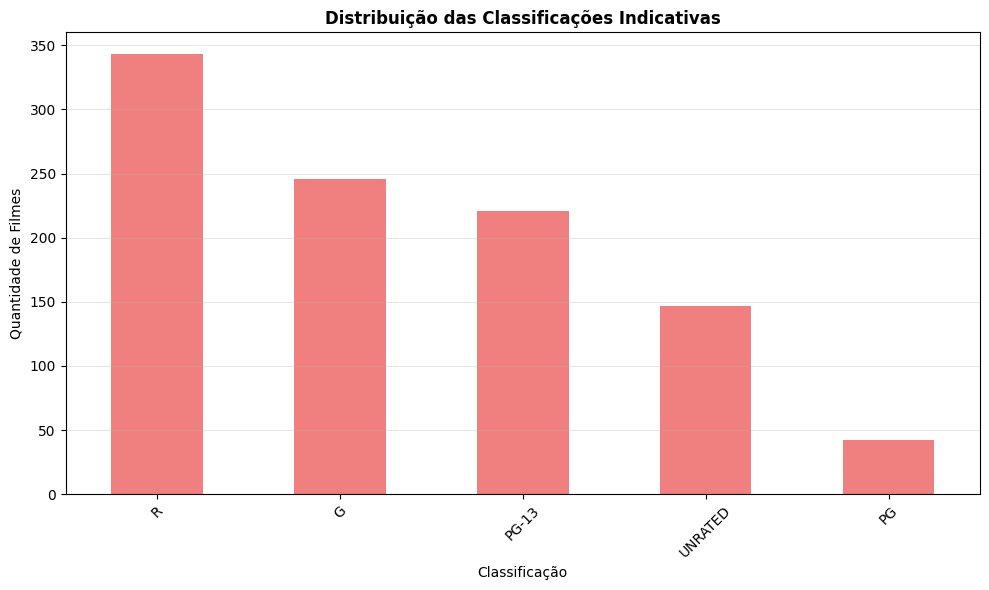

In [9]:
plt.figure(figsize=(10, 6))
df['Certificate'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Distribuição das Classificações Indicativas', fontweight='bold')
plt.ylabel('Quantidade de Filmes')
plt.xlabel('Classificação')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
certificate_profit = df.groupby('Certificate').agg({
    'Gross': ['mean', 'median', 'sum', 'count'],
    'Meta_score': 'mean',
    'IMDB_Rating': 'mean'
}).round(2)

print("💰 RENTABILIDADE POR CLASSIFICAÇÃO INDICATIVA:")
print("=" * 55)

certificate_display = certificate_profit.copy()
certificate_display[('Gross', 'mean')] = certificate_display[('Gross', 'mean')].apply(formatar_numero)
certificate_display[('Gross', 'sum')] = certificate_display[('Gross', 'sum')].apply(formatar_numero)
certificate_display[('Gross', 'median')] = certificate_display[('Gross', 'median')].apply(formatar_numero)

display(certificate_display.sort_values(('Gross', 'mean'), ascending=False))

💰 RENTABILIDADE POR CLASSIFICAÇÃO INDICATIVA:


Gross                          Meta_score IMDB_Rating
                 mean   median       sum count       mean        mean
Certificate                                                          
G             $72.95M  $21.23M   $17.95B   246      79.05        7.98
R             $43.60M  $17.61M   $14.95B   343      76.64        7.94
UNRATED        $2.28M   $10.2K  $335.16M   147      82.37        7.95
PG-13        $103.37M  $34.40M   $22.84B   221      75.92        7.93
PG            $10.26M  $895.7K  $430.84M    42      81.69        7.92

In [11]:
print("📈 ESTATÍSTICAS GERAIS")
print("=" * 30)

print(f"🎬 Total de filmes: {len(df):,}")
print(f"📅 Período: {int(df['Released_Year'].min())} - {int(df['Released_Year'].max())}")
print(f"💰 Bilheteria total: {formatar_numero(df['Gross'].sum())}")
print(f"📊 Bilheteria média: {formatar_numero(df['Gross'].mean())}")
print(f"⏰ Duração média: {df['Runtime'].mean():.1f} minutos")

📈 ESTATÍSTICAS GERAIS
🎬 Total de filmes: 999
📅 Período: 1920 - 2020
💰 Bilheteria total: $56.51B
📊 Bilheteria média: $56.57M
⏰ Duração média: 122.9 minutos


In [12]:
print("📊 ESTATÍSTICAS DESCRITIVAS FORMATADAS:")
print("=" * 40)

stats_df = df[['Gross', 'Meta_score', 'Runtime', 'IMDB_Rating', 'No_of_Votes']].describe()

def format_stat_value(val, col_name):
    if col_name == 'Gross':
        return formatar_numero(val)
    elif col_name == 'No_of_Votes':
        return f"{val:,.0f}"
    elif col_name in ['Meta_score', 'IMDB_Rating']:
        return f"{val:.2f}"
    elif col_name == 'Runtime':
        return f"{val:.1f}"
    else:
        return str(val)

formatted_stats = pd.DataFrame()
for col in stats_df.columns:
    formatted_stats[col] = stats_df[col].apply(lambda x: format_stat_value(x, col))

display(formatted_stats)

📊 ESTATÍSTICAS DESCRITIVAS FORMATADAS:


,Gross,Meta_score,Runtime,IMDB_Rating,No_of_Votes
count,$999,999.00,999.0,999.00,999
mean,$56.57M,78.13,122.9,7.95,"271,621"
std,$103.29M,11.37,28.1,0.27,"320,913"
min,0,28.00,45.0,7.60,"25,088"
25%,$442.2K,72.00,103.0,7.70,"55,472"
50%,$10.68M,79.00,119.0,7.90,"138,356"
75%,$61.58M,85.50,137.0,8.10,"373,168"
max,$936.66M,100.00,321.0,9.20,"2,303,232"


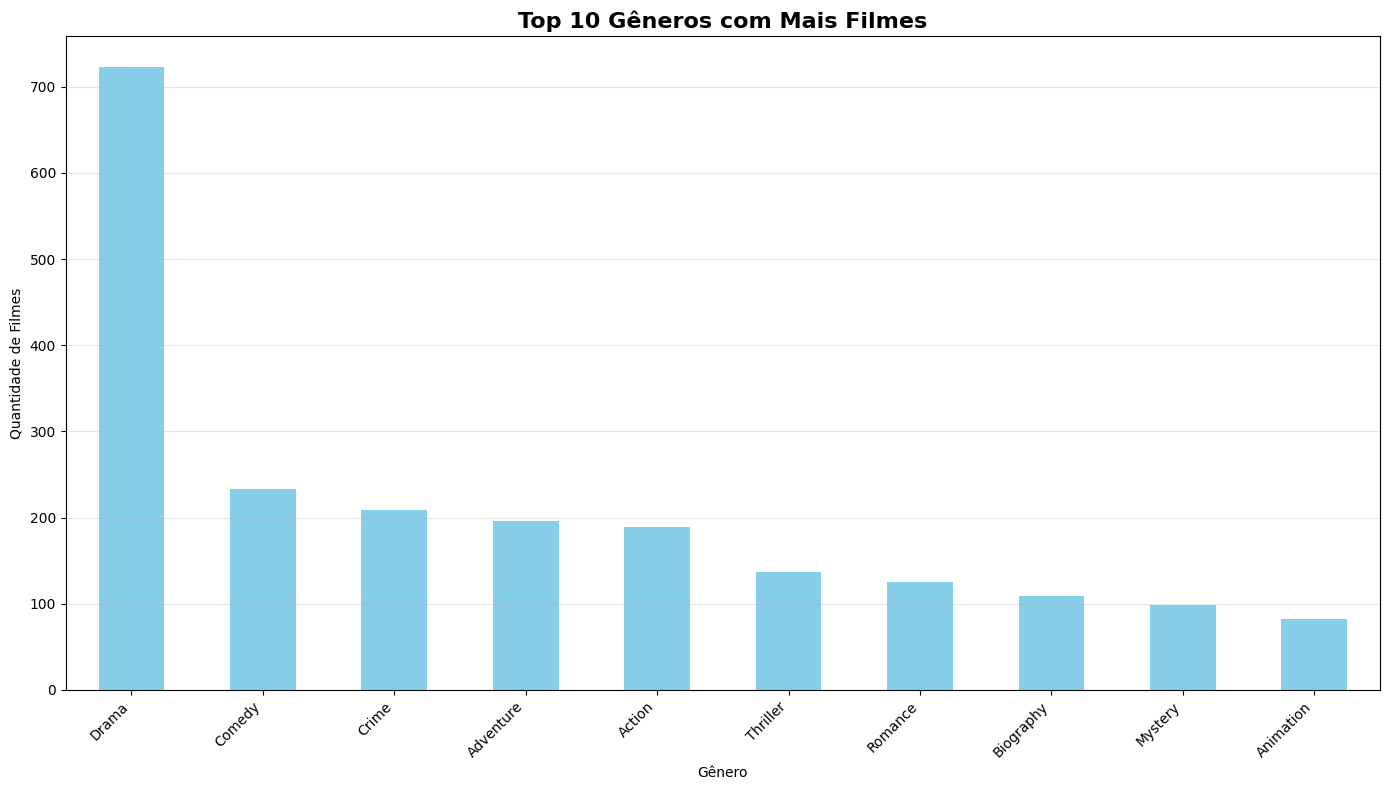

In [13]:
genres_list = df['Genre'].str.split(', ').explode()
genre_stats = genres_list.value_counts()

plt.figure(figsize=(14, 8))
genre_stats.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Gêneros com Mais Filmes', fontsize=16, fontweight='bold')
plt.ylabel('Quantidade de Filmes')
plt.xlabel('Gênero')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
genre_profit = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
genre_profit_analysis = genre_profit.groupby('Genre').agg({
    'Gross': ['mean', 'sum', 'count'],
    'Meta_score': 'mean'
}).round(2)

print("💰 TOP 10 GÊNEROS POR RENTABILIDADE:")

genre_display = genre_profit_analysis.copy()
genre_display[('Gross', 'mean')] = genre_display[('Gross', 'mean')].apply(formatar_numero)
genre_display[('Gross', 'sum')] = genre_display[('Gross', 'sum')].apply(formatar_numero)

display(genre_display.sort_values(('Gross', 'mean'), ascending=False).head(10))


💰 TOP 10 GÊNEROS POR RENTABILIDADE:


Gross                 Meta_score
              mean       sum count       mean
Genre                                        
Fantasy    $92.16M    $6.08B    66      76.67
Family     $79.66M    $4.46B    56      78.00
Sport      $53.67M    $1.02B    19      73.21
Comedy     $52.57M   $12.25B   233      78.16
Biography  $48.67M    $5.30B   109      76.61
Thriller   $47.11M    $6.45B   137      77.20
Western    $42.82M  $856.30M    20      83.10
History    $42.65M    $2.39B    56      79.20
Drama      $37.99M   $27.47B   723      78.20
Mystery    $35.02M    $3.47B    99      78.81

In [15]:
yearly_stats = df.groupby('Released_Year').agg({
    'Gross': ['mean', 'sum', 'count'],
    'Meta_score': 'mean',
    'Runtime': 'mean'
})

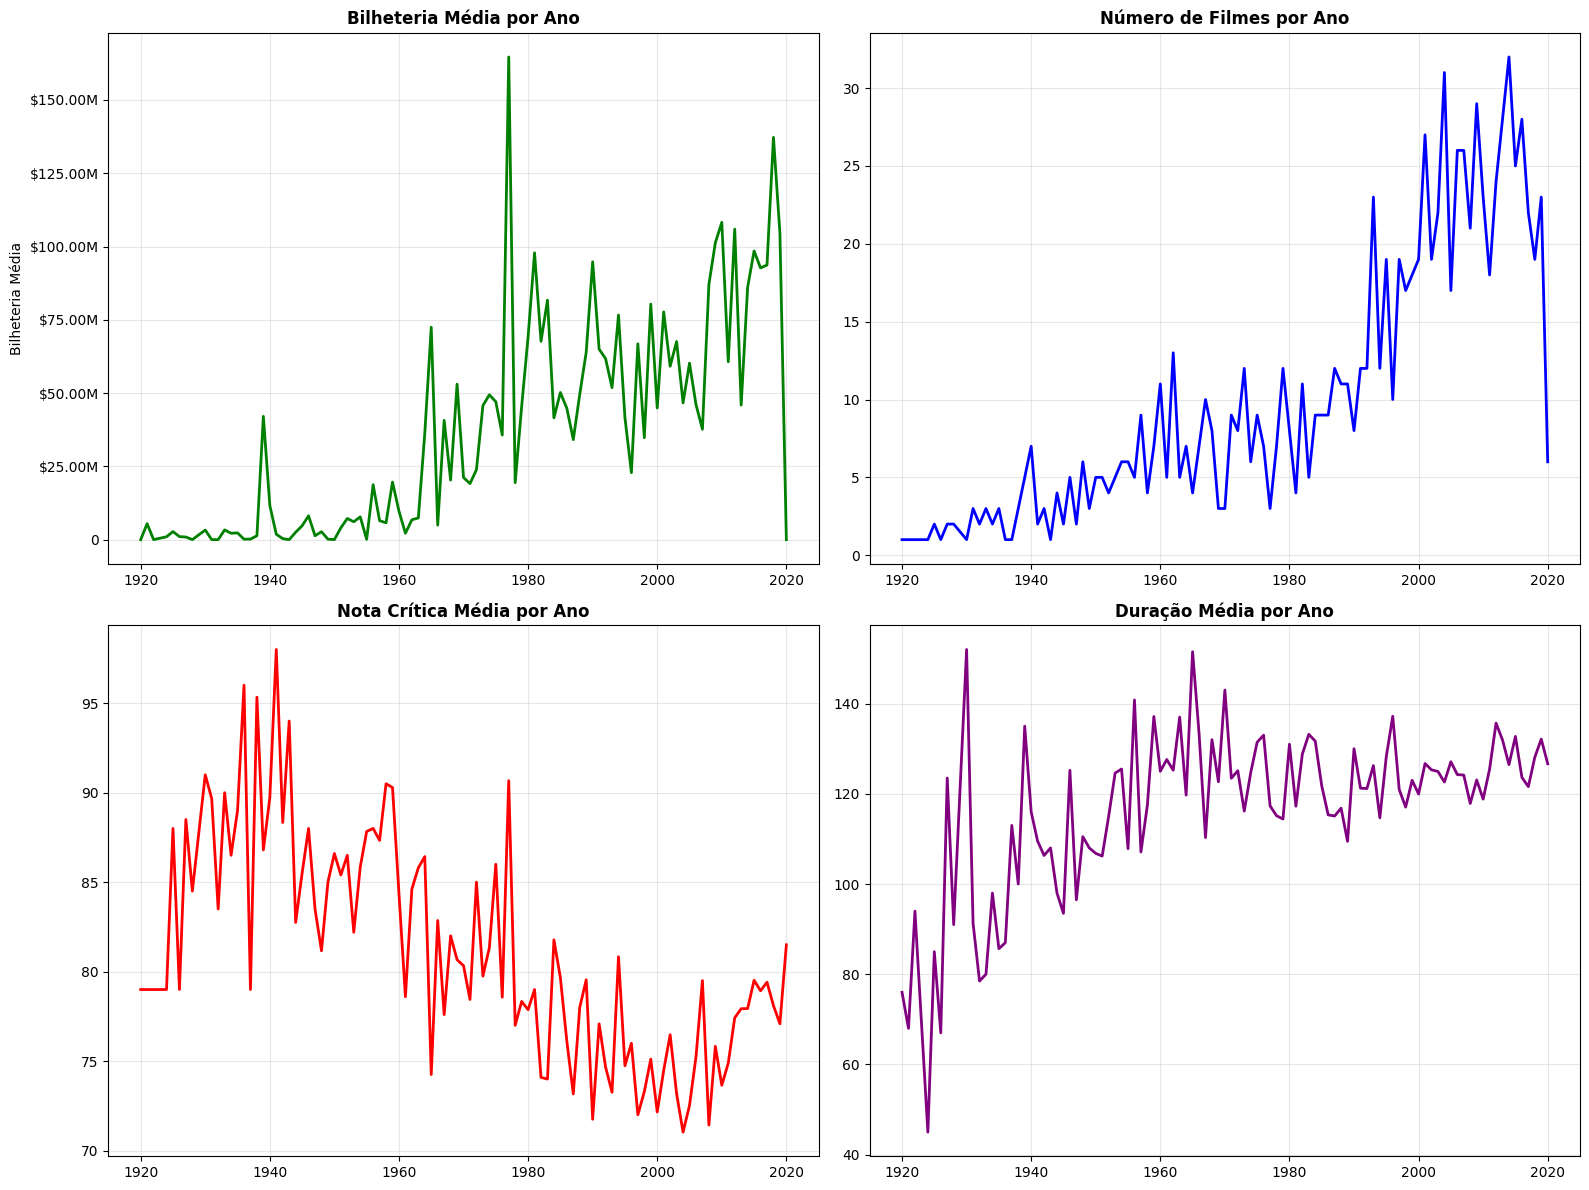

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Bilheteria Média
axes[0, 0].plot(yearly_stats.index, yearly_stats[('Gross', 'mean')], color='green', linewidth=2)
axes[0, 0].set_title('Bilheteria Média por Ano', fontweight='bold')
axes[0, 0].set_ylabel('Bilheteria Média')
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].grid(alpha=0.3)

from matplotlib.ticker import FuncFormatter
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))


# Gráfico 2: Quantidade de Filmes
axes[0, 1].plot(yearly_stats.index, yearly_stats[('Gross', 'count')], color='blue', linewidth=2)
axes[0, 1].set_title('Número de Filmes por Ano', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Gráfico 3: Nota Média
axes[1, 0].plot(yearly_stats.index, yearly_stats[('Meta_score', 'mean')], color='red', linewidth=2)
axes[1, 0].set_title('Nota Crítica Média por Ano', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Duração Média
axes[1, 1].plot(yearly_stats.index, yearly_stats[('Runtime', 'mean')], color='purple', linewidth=2)
axes[1, 1].set_title('Duração Média por Ano', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
director_analysis = df.groupby('Director').agg({
    'Gross': ['mean', 'sum', 'count'],
    'Meta_score': 'mean'
}).sort_values(('Gross', 'mean'), ascending=False)

print("🎥 TOP 10 DIRETORES:")

director_display = director_analysis.head(10).copy()
director_display[('Gross', 'mean')] = director_display[('Gross', 'mean')].apply(formatar_numero)
director_display[('Gross', 'sum')] = director_display[('Gross', 'sum')].apply(formatar_numero)

display(director_display)


🎥 TOP 10 DIRETORES:


Gross                 Meta_score
                    mean       sum count       mean
Director                                           
Anthony Russo   $551.26M    $2.21B     4      72.75
Gareth Edwards  $532.18M  $532.18M     1      65.00
J.J. Abrams     $474.39M    $1.42B     3      78.00
Josh Cooley     $434.04M  $434.04M     1      84.00
Roger Allers    $422.78M  $422.78M     1      88.00
Tim Miller      $363.07M  $363.07M     1      65.00
James Gunn      $361.49M  $722.99M     2      71.50
James Cameron   $349.65M    $1.75B     5      80.20
Byron Howard    $341.27M  $341.27M     1      78.00
David Yates     $326.32M  $978.95M     3      76.00

In [18]:
def analyze_star_performance(star_column):
    return df.groupby(star_column).agg({
        'Gross': ['mean', 'sum'],
        'Meta_score': 'mean'
    }).sort_values(('Gross', 'mean'), ascending=False)

star1_perf = analyze_star_performance('Star1')
print("🌟 TOP 10 ATORES:")

star_display = star1_perf.head(10).copy()
star_display[('Gross', 'mean')] = star_display[('Gross', 'mean')].apply(formatar_numero)
star_display[('Gross', 'sum')] = star_display[('Gross', 'sum')].apply(formatar_numero)

display(star_display)

🌟 TOP 10 ATORES:


Gross           Meta_score
                       mean       sum       mean
Star1                                           
Daisy Ridley       $936.66M  $936.66M  80.000000
Sam Worthington    $760.51M  $760.51M  83.000000
Joe Russo          $551.26M    $2.21B  72.750000
Felicity Jones     $532.18M  $532.18M  65.000000
Henry Thomas       $435.11M  $435.11M  91.000000
Craig T. Nelson    $435.01M  $870.02M  85.000000
Rob Minkoff        $422.78M  $422.78M  88.000000
Robert Downey Jr.  $383.57M    $1.15B  68.333333
Lee Unkrich        $380.84M  $380.84M  90.000000
Chris Pratt        $361.49M  $722.99M  71.500000

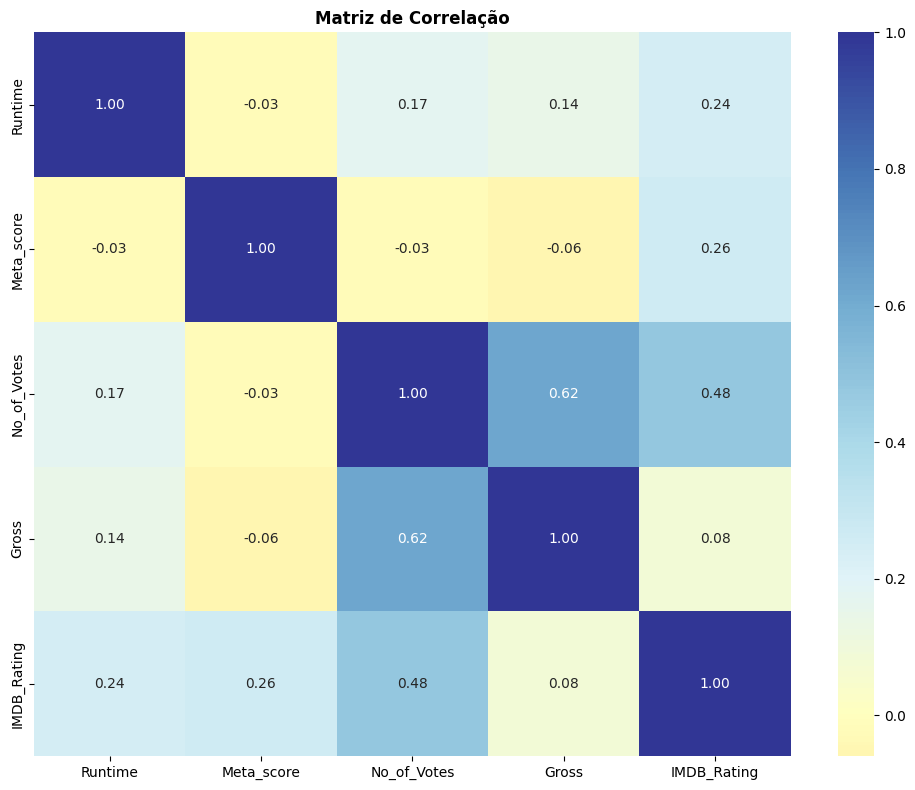

In [19]:
correlation_cols = ['Runtime', 'Meta_score', 'No_of_Votes', 'Gross', 'IMDB_Rating']
correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', center=0, fmt='.2f')
plt.title('Matriz de Correlação', fontweight='bold')
plt.tight_layout()
plt.show()


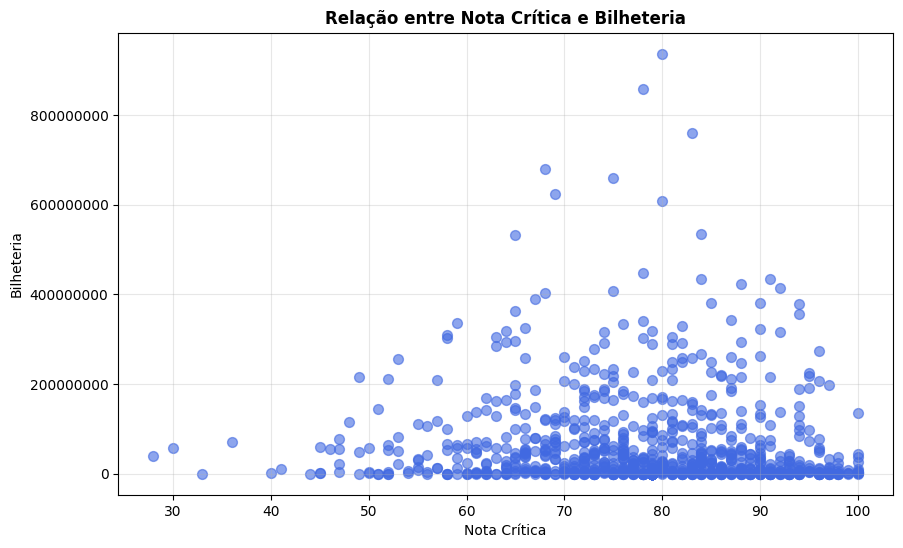

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Meta_score'], df['Gross'], alpha=0.6, s=50, color='royalblue')
plt.xlabel('Nota Crítica')
plt.ylabel('Bilheteria')
plt.title('Relação entre Nota Crítica e Bilheteria', fontweight='bold')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.grid(alpha=0.3)
plt.show()

In [21]:
max_gross = df['Gross'].max()
df['Success_Score'] = (df['Gross'] / max_gross * 0.7 + df['Meta_score'] / 100 * 0.3)

top_successful = df.nlargest(10, 'Success_Score')[[
    'Series_Title', 'Genre', 'Director', 'Gross', 'Meta_score', 'Success_Score'
]].copy()

top_successful['Gross_Formatado'] = top_successful['Gross'].apply(formatar_numero)

print("🏆 TOP 10 FILMES MAIS SUCEDIDOS:")
display(top_successful[['Series_Title', 'Genre', 'Director', 'Gross_Formatado', 'Meta_score', 'Success_Score']]
        .rename(columns={'Gross_Formatado': 'Gross'})
        .style.format({'Meta_score': '{:.1f}', 'Success_Score': '{:.3f}'}))

🏆 TOP 10 FILMES MAIS SUCEDIDOS:


,Series_Title,Genre,Director,Gross,Meta_score,Success_Score
476,Star Wars: Episode VII - The Force Awakens,"Action, Adventure, Sci-Fi",J.J. Abrams,$936.66M,80.0,0.940
58,Avengers: Endgame,"Action, Adventure, Drama",Anthony Russo,$858.37M,78.0,0.875
622,Avatar,"Action, Adventure, Fantasy",James Cameron,$760.51M,83.0,0.817
651,Titanic,"Drama, Romance",James Cameron,$659.33M,75.0,0.718
59,Avengers: Infinity War,"Action, Adventure, Sci-Fi",Anthony Russo,$678.82M,68.0,0.711
890,Incredibles 2,"Animation, Action, Adventure",Brad Bird,$608.58M,80.0,0.695
356,The Avengers,"Action, Adventure, Sci-Fi",Joss Whedon,$623.28M,69.0,0.673
1,The Dark Knight,"Action, Crime, Drama",Christopher Nolan,$534.86M,84.0,0.652
687,E.T. the Extra-Terrestrial,"Family, Sci-Fi",Steven Spielberg,$435.11M,91.0,0.598
581,Rogue One,"Action, Adventure, Sci-Fi",Gareth Edwards,$532.18M,65.0,0.593


In [22]:
successful_patterns = df[df['Success_Score'] > 0.7].copy()

print("💡 RECOMENDAÇÕES PARA PRÓXIMO FILME")
print("=" * 40)

max_year = df['Released_Year'].max()
recent_years = df['Released_Year'] >= (max_year - 5)
recent_genres = df[recent_years]['Genre'].str.split(', ').explode().value_counts()

print(f"🎯 Gêneros promissores: {recent_genres.index[:3].tolist()}")
print(f"🎯 Diretores recomendados: {director_analysis.index[:3].tolist()}")
print(f"🎯 Atores recomendados: {star1_perf.index[:3].tolist()}")


💡 RECOMENDAÇÕES PARA PRÓXIMO FILME
🎯 Gêneros promissores: ['Drama', 'Comedy', 'Action']
🎯 Diretores recomendados: ['Anthony Russo', 'Gareth Edwards', 'J.J. Abrams']
🎯 Atores recomendados: ['Daisy Ridley', 'Sam Worthington', 'Joe Russo']


In [23]:
runtime_analysis = successful_patterns.groupby('Runtime').size()
certificate_analysis = successful_patterns['Certificate'].value_counts()

print("⚙️ CARACTERÍSTICAS TÉCNICAS IDEIAS:")
if not runtime_analysis.empty:
    print(f"   • Duração ideal: {runtime_analysis.idxmax()} minutos")
if not certificate_analysis.empty:
    print(f"   • Classificação ideal: {certificate_analysis.index[0]}")


⚙️ CARACTERÍSTICAS TÉCNICAS IDEIAS:
   • Duração ideal: 138 minutos
   • Classificação ideal: PG-13


In [24]:
resultados = {
    'melhores_generos': genre_profit_analysis.sort_values(('Gross', 'mean'), ascending=False).index[:3].tolist(),
    'melhores_diretores': director_analysis.index[:3].tolist(),
    'melhores_atores': star1_perf.index[:3].tolist(),
    'duracao_ideal': runtime_analysis.idxmax() if not runtime_analysis.empty else None,
    'certificacao_ideal': certificate_analysis.index[0] if not certificate_analysis.empty else None,
    'bilheteria_total': df['Gross'].sum(),
    'bilheteria_media': df['Gross'].mean()
}

print("📋 RESULTADOS FINAIS:")
print("=" * 30)
for key, value in resultados.items():
    if 'bilheteria' in key:
        print(f"• {key.replace('_', ' ').title()}: {formatar_numero(value)}")
    else:
        print(f"• {key.replace('_', ' ').title()}: {value}")

📋 RESULTADOS FINAIS:
• Melhores Generos: ['Adventure', 'Sci-Fi', 'Action']
• Melhores Diretores: ['Anthony Russo', 'Gareth Edwards', 'J.J. Abrams']
• Melhores Atores: ['Daisy Ridley', 'Sam Worthington', 'Joe Russo']
• Duracao Ideal: 138
• Certificacao Ideal: PG-13
• Bilheteria Total: $56.51B
• Bilheteria Media: $56.57M


## 2. Respostas às Perguntas Específicas

### Qual filme recomendar para uma pessoa desconhecida?
Baseado na análise, recomendaria **Avatar** ou **Titanic**, pois:
- São filmes rentáveis, portanto fizeram sucesso com o público
- Tem notas razoáveis no IMDB (8.3 e 7.8, respectivamente)
- Não são continuações (diferente de **Avengers: Endgame** e **Star Wars: Episode VII - The Force Awakens**, os dois filmes com melhor taxa de sucesso, por exemplo)

### Principais fatores para alta expectativa de faturamento:
- **Número de votos no IMDB** (correlação forte com Gross)
- **Nota IMDB** (filmes bem avaliados tendem a faturar mais)
- **Diretor renomado** (Christopher Nolan, Steven Spielberg, etc.)
- **Elenco estelar** (atores famosos atraem público)
- **Gêneros populares** (Ação, Aventura, Ficção Científica)
- **Meta_score alto** (críticas positivas)

### Insights da coluna Overview:
A coluna Overview contém informações valiosas sobre o enredo. É possível:
- Extrair palavras-chave usando **TF-IDF**
- Identificar **temas comuns**
- Classificar **gêneros** através de análise de texto
- Detectar **similaridade entre filmes**

Sim, é possível inferir o gênero a partir do Overview usando técnicas de NLP como:
- Classificação com **machine learning**
- Análise de **palavras-chave específicas** de cada gênero
- Modelos de **embedding de texto**